# Evaluation of CelebA Ensemble Counterfactuals

This notebook re-implements the model architecture and data setup from `celebA_ensemble.ipynb` to evaluate the raw scores of the counterfactuals using the original latent training distribution.

In [1]:
import os
import torch
import torch.nn as nn
import pickle
import numpy as np
import pandas as pd
import sys
import kagglehub
from PIL import Image
from torch.utils.data import DataLoader
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path to import explainers_lib
sys.path.append(os.path.abspath('../src'))
from explainers_lib.counterfactual import Counterfactual
from explainers_lib.aggregators import Pareto, IdealPoint, BalancedPoint, TOPSIS, All, DensityBased, ParetoMeanPoint
from explainers_lib.datasets import Dataset
from explainers_lib.model import TorchModel
from explainers_lib.ensemble import cfs_group_by_original_data
from explainers_lib.utils.scores import get_scores

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


/home/berni/education/counterfactuals/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Data Preparation (CelebA)

Downloading and preparing the dataset as in the original experiment.

In [2]:
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
img_dir = os.path.join(path, "img_align_celeba/img_align_celeba")
attr_path = os.path.join(path, "list_attr_celeba.csv")

df = pd.read_csv(attr_path)
df = df.rename(columns=lambda s: s.strip())

df["Smiling"] = df["Smiling"].apply(lambda x: 1 if x == 1 else 0)
df["class"] = df["Smiling"]

train_df, test_df = train_test_split(df, test_size=1000, shuffle=True, random_state=42)

transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

class Celeb4ClassDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        label = torch.tensor(row["class"], dtype=torch.long)
        return img, label

train_ds = Celeb4ClassDataset(train_df, img_dir, transform)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)


## 2. Model Definition and Weight Loading

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2)
        )
    def forward(self, x): return self.block(x)

class TransConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c), nn.LeakyReLU(0.2)
        )
    def forward(self, x): return self.block(x)

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 64), ConvBlock(64, 128),
            ConvBlock(128, 256), ConvBlock(256, 512), ConvBlock(512, 512),
            nn.Flatten(), nn.Linear(512 * 2 * 2, latent_dim), nn.Tanh()
        )
    def forward(self, x): return self.encoder(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(latent_dim, 512 * 2 * 2), nn.Tanh())
        self.decoder = nn.Sequential(
            TransConvBlock(512, 512), TransConvBlock(512, 512),
            TransConvBlock(512, 256), TransConvBlock(256, 128),
            TransConvBlock(128, 64), TransConvBlock(64, 32),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1), nn.Tanh()
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 512, 2, 2)
        return self.decoder(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        flatten_dim = 32 * 32 * 32

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class LatentToClassPipeline(nn.Module):
    def __init__(self, decoder, cnn):
        super().__init__()
        self.decoder, self.cnn = decoder, cnn
    def forward(self, x):
        decoded = self.decoder(x) * 0.5
        return self.cnn(decoded)

encoder = Encoder(latent_dim=128).to(device)
decoder = Decoder(latent_dim=128).to(device)
weights = torch.load('autoencoder_celeba_best.pth', map_location='cuda')

encoder.load_state_dict({k[len('encoder.'):]: v for k, v in weights.items() if k.startswith('encoder.')})
decoder.load_state_dict({k[len('decoder.'):]: v for k, v in weights.items() if k.startswith('decoder.')})
encoder.eval()
decoder.eval()

cnn = CNN()
cnn.load_state_dict(torch.load('models/torch_cnn_celeba_paper_smile_only.pth', map_location='cuda'))
cnn.to(device).eval()

pipeline = LatentToClassPipeline(decoder, cnn).to(device).eval()
model = TorchModel(pipeline)


## 3. Prepare Latent Training Dataset

Getting latent representations for training data samples as in `celebA_ensemble.ipynb`.

In [4]:
root = path
img_dir = root + "/img_align_celeba/img_align_celeba"
attr_path = os.path.join(root, "list_attr_celeba.csv")


df = pd.read_csv(attr_path)
df = df.rename(columns=lambda s: s.strip())

df["class"] = df["Smiling"].apply(lambda x: 1 if x == 1 else 0)

train_df, test_df = train_test_split(df, test_size=1000, shuffle=True, random_state=42)

train_df, val_df = train_test_split(train_df, test_size=0.1, shuffle=True, random_state=42)

transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize((0.5,)*3, (0.5,)*3)
])

class Celeb4ClassDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row["class"], dtype=torch.long)
        return img, label

train_ds = Celeb4ClassDataset(train_df, img_dir, transform)
val_ds = Celeb4ClassDataset(val_df, img_dir, transform)
test_ds = Celeb4ClassDataset(test_df, img_dir, transform)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)


In [5]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.block(x)

class TransConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_c),
            nn.LeakyReLU(0.2)
        )
    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(3,   32),   # 128 -> 64
            ConvBlock(32,  64),   # 64 -> 32
            ConvBlock(64,  128),  # 32 -> 16
            ConvBlock(128, 256),  # 16 -> 8
            ConvBlock(256, 512),  # 8 W-> 4
            ConvBlock(512, 512),  # 4 -> 2
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, latent_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.encoder(x)
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512 * 2 * 2),
            nn.Tanh()
        )

        self.decoder = nn.Sequential(
            TransConvBlock(512, 512),   # 2 → 4
            TransConvBlock(512, 512),   # 4 → 8
            TransConvBlock(512, 256),   # 8 → 16
            TransConvBlock(256, 128),   # 16 → 32
            TransConvBlock(128, 64),    # 32 → 64
            TransConvBlock(64, 32),     # 64 → 128
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 2, 2)
        x = self.decoder(x)
        return x
    
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim).to(device)
        self.decoder = Decoder(latent_dim).to(device)

    def forward(self, x):
        return self.decoder(self.encoder(x))


In [6]:
import torch

autoencoder = Autoencoder(latent_dim=128).to(device)

weights = torch.load("autoencoder_celeba_best.pth", map_location=device)

autoencoder.load_state_dict(weights)

autoencoder.eval()


Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.2)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.2)
        )
      )
      (2): ConvBlock(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.2)
        )
      )
      (3): ConvBlock(
        (block): Sequential(
          (0): C

In [7]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder


n_samples = 10_000

batch = next(iter(train_dl))
images_batch, labels_batch = batch
imgs = images_batch[:n_samples].to(device)
targets = labels_batch[:n_samples].cpu().tolist()

with torch.no_grad():
    latent_tensors = autoencoder.encoder(imgs)

latent_instance_np = latent_tensors.cpu().detach().numpy()
latent_dim_actual = latent_instance_np.shape[1]
feature_names = [f'l{i}' for i in range(latent_dim_actual)]

data_df = pd.DataFrame(latent_instance_np, columns=feature_names)

identity = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', feature_names),
        # ("cat", OneHotEncoder(), []),

    ],    remainder='drop'
)
identity.fit(data_df)


latent_dataset_train = Dataset(
    df=data_df,
    target=targets,
    features=feature_names,
    categorical_features=[],
    continuous_features=feature_names,
    immutable_features=[],
    allowable_ranges={},
    preprocessor=identity
)


In [8]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder


n_samples = 3

batch = next(iter(test_dl))
images_batch, labels_batch = batch
imgs = images_batch[:n_samples].to(device)
targets = labels_batch[:n_samples].cpu().tolist()

with torch.no_grad():
    latent_tensors = autoencoder.encoder(imgs)

latent_instance_np = latent_tensors.cpu().detach().numpy()
latent_dim_actual = latent_instance_np.shape[1]
feature_names = [f'l{i}' for i in range(latent_dim_actual)]

data_df = pd.DataFrame(latent_instance_np, columns=feature_names)

identity = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', feature_names),
    ],    remainder='drop'
)

identity.fit(data_df)

latent_dataset = Dataset(
    df=data_df,
    target=targets,
    features=feature_names,
    categorical_features=[],
    continuous_features=feature_names,
    immutable_features=[],
    allowable_ranges={},
    preprocessor=identity
)


## 4. Evaluate Scored Counterfactuals

In [9]:
with open('results/celeba_ensemble.pkl', 'rb') as f:
    cfs = pickle.load(f)

for cf in cfs:
    if not hasattr(cf, 'metadata'): cf.metadata = {}

evaluator = All()
evaluator.fit(model, latent_dataset_train)
scored_cfs = evaluator(cfs, include_scores=True)

selectors = {
    "Pareto": Pareto(),
    "IdealPoint": IdealPoint(),
    "BalancedPoint": BalancedPoint(),
    "ParetoMeanPoint": ParetoMeanPoint(),
    "TOPSIS": TOPSIS(k=1),
    "DensityBased": DensityBased(k=1)
}

for name, s in selectors.items():
    s.fit(model, latent_dataset_train)

grouped_cfs = cfs_group_by_original_data(scored_cfs)

for original_idx, group in grouped_cfs.items():
    for name, selector in selectors.items():
        selected = selector(group)
        for cf in selected:
            if 'selected_by' not in cf.metadata:
                cf.metadata['selected_by'] = []
            if name not in cf.metadata['selected_by']:
                cf.metadata['selected_by'].append(name)

df_scores = pd.DataFrame([
    {**{'ID': i, 'Explainer': cf.explainer[:15]}, **cf.metadata['scores']}
    for i, cf in enumerate(scored_cfs)
])
df_scores


,ID,Explainer,Proximity,Feasibility,K_Feasibility(3),FeaturesChanged,DiscriminativePower(9)
0,0,growing_spheres,19.981445,30.640015,31.871509,0.648438,0.555556
1,1,face_explainer(,34.841346,27.151994,28.184147,0.976562,0.777778
2,2,dice_explainer(,1.897260,33.133649,33.610094,0.023438,0.444444
3,3,cfproto(),18.907090,28.523076,29.753638,0.531250,0.555556
4,4,cfrl_celeba(lat,44.902278,30.522552,32.209957,1.000000,0.555556
5,5,growing_spheres,40.879914,31.226985,32.131139,0.937500,0.555556
6,6,face_explainer(,34.841346,27.151994,28.184147,0.976562,0.777778
7,7,dice_explainer(,43.406420,32.265946,32.956742,0.976562,0.444444
8,8,cfproto(),40.963395,28.778058,30.922276,0.976562,0.666667
9,9,cfrl_celeba(lat,42.497796,30.596147,31.699136,1.000000,0.333333


## 5. Visualizing the Aggregate Metrics

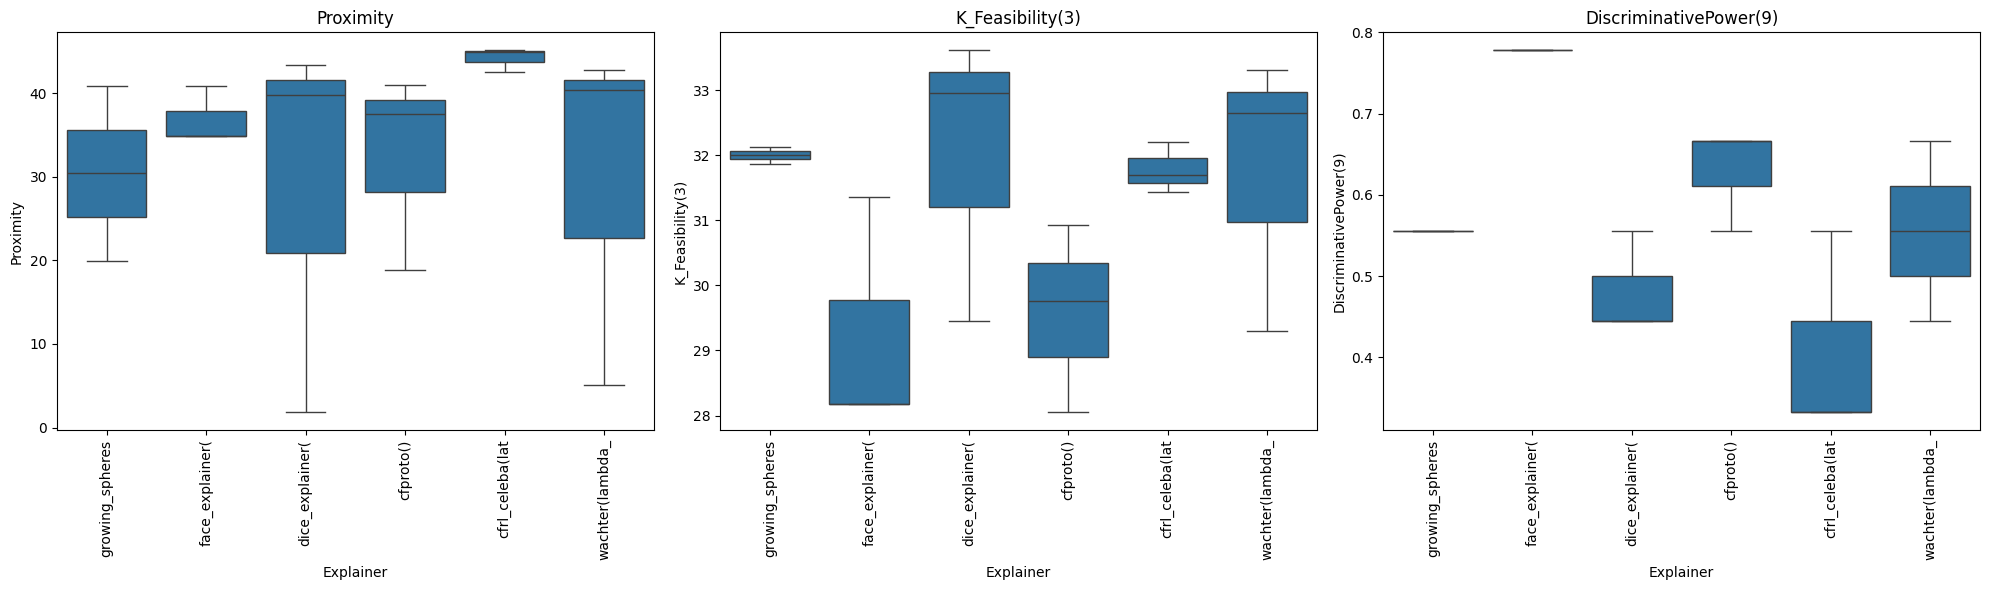

In [10]:
metrics = ['Proximity', 'K_Feasibility(3)', 'DiscriminativePower']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, metric in enumerate(metrics):
    col = next((c for c in df_scores.columns if metric in c), metric)
    if col in df_scores.columns:
        sns.boxplot(data=df_scores, x='Explainer', y=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()


## 6. Visualizing Each Counterfactual with Metrics

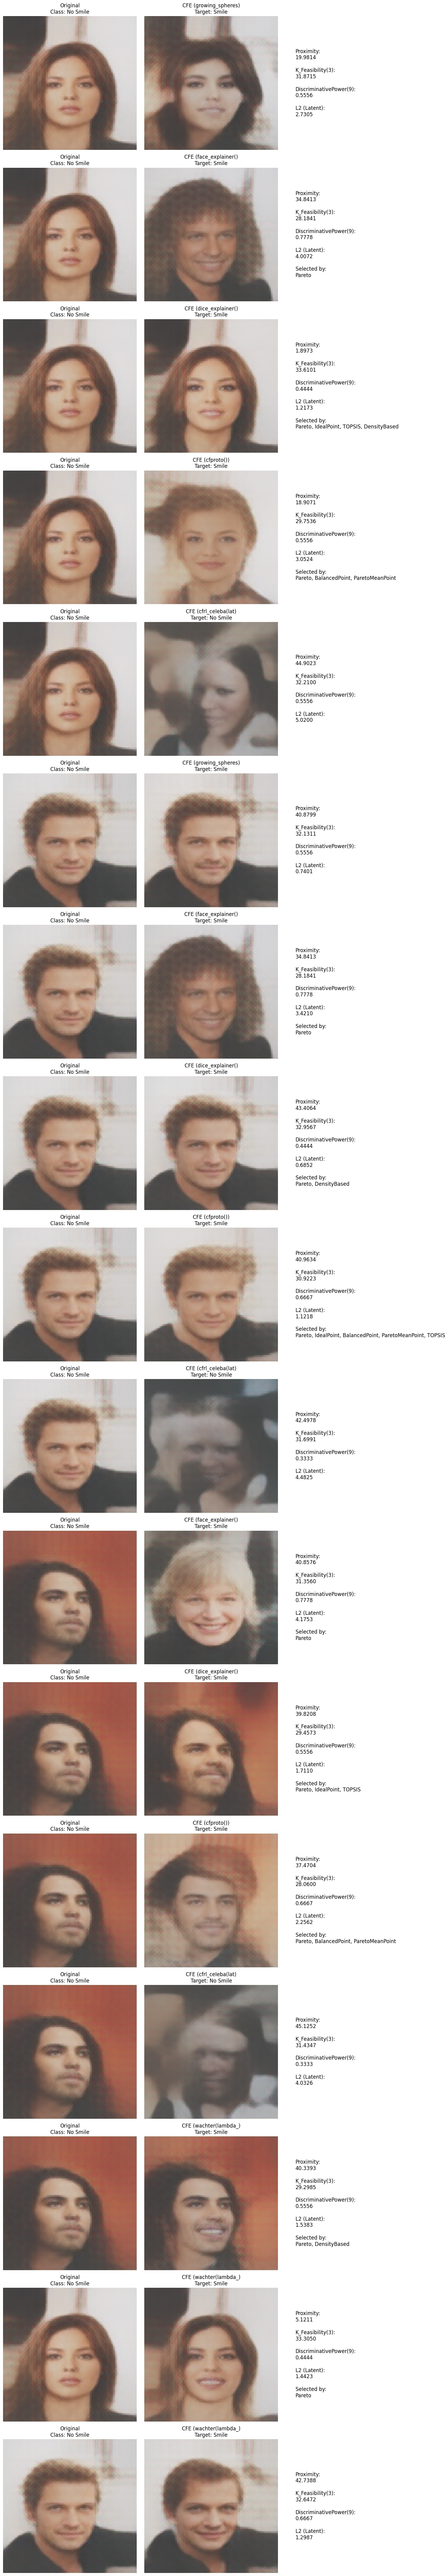

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch

class_map = {
    0: "No Smile",
    1: "Smile"
}

def plot_scored_cfes(cfes, decoder, device, metrics_to_show=['Proximity', 'K_Feasibility(3)', 'DiscriminativePower(9)']):
    n = len(cfes)
    if n == 0: return
    
    fig, axes = plt.subplots(n, 3, figsize=(16, 5 * n))
    
    if n == 1: axes = np.expand_dims(axes, axis=0)
    
    for i, cf in enumerate(cfes):
        with torch.no_grad():
            latent_orig = torch.tensor(cf.original_data, dtype=torch.float32, device=device).unsqueeze(0)
            img_orig = decoder(latent_orig).cpu().squeeze().permute(1, 2, 0).numpy()
            img_orig = (img_orig + 1) / 2 # [-1, 1] -> [0, 1]
            
            latent_cf = torch.tensor(cf.data, dtype=torch.float32, device=device).unsqueeze(0)
            img_cf = decoder(latent_cf).cpu().squeeze().permute(1, 2, 0).numpy()
            img_cf = (img_cf + 1) / 2
        
        axes[i, 0].imshow(np.clip(img_orig, 0, 1))
        axes[i, 0].set_title(f"Original\nClass: {class_map.get(cf.original_class, cf.original_class)}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(np.clip(img_cf, 0, 1))
        axes[i, 1].set_title(f"CFE ({cf.explainer[:15]})\nTarget: {class_map.get(cf.target_class, cf.target_class)}")
        axes[i, 1].axis('off')
        
        scores = cf.metadata.get('scores', {})
        
        metrics_list = [
            f"{m}:\n{scores.get(m, 'N/A'):.4f}" if isinstance(scores.get(m), (float, int)) 
            else f"{m}:\n{scores.get(m, 'N/A')}" for m in metrics_to_show
        ]
        
        l2_distance = np.linalg.norm(cf.original_data - cf.data)
        metrics_list.append(f"L2 (Latent):\n{l2_distance:.4f}")
        
        selected_by = cf.metadata.get('selected_by', [])
        if selected_by:
            metrics_list.append(f"Selected by:\n{', '.join(selected_by)}")
        
        metrics_text = "\n\n".join(metrics_list)
        
        axes[i, 2].axis('off')
        axes[i, 2].text(0.1, 0.5, metrics_text, fontsize=12, va='center', ha='left')
    
    plt.tight_layout()
    plt.show()

plot_scored_cfes(scored_cfs, decoder, device)


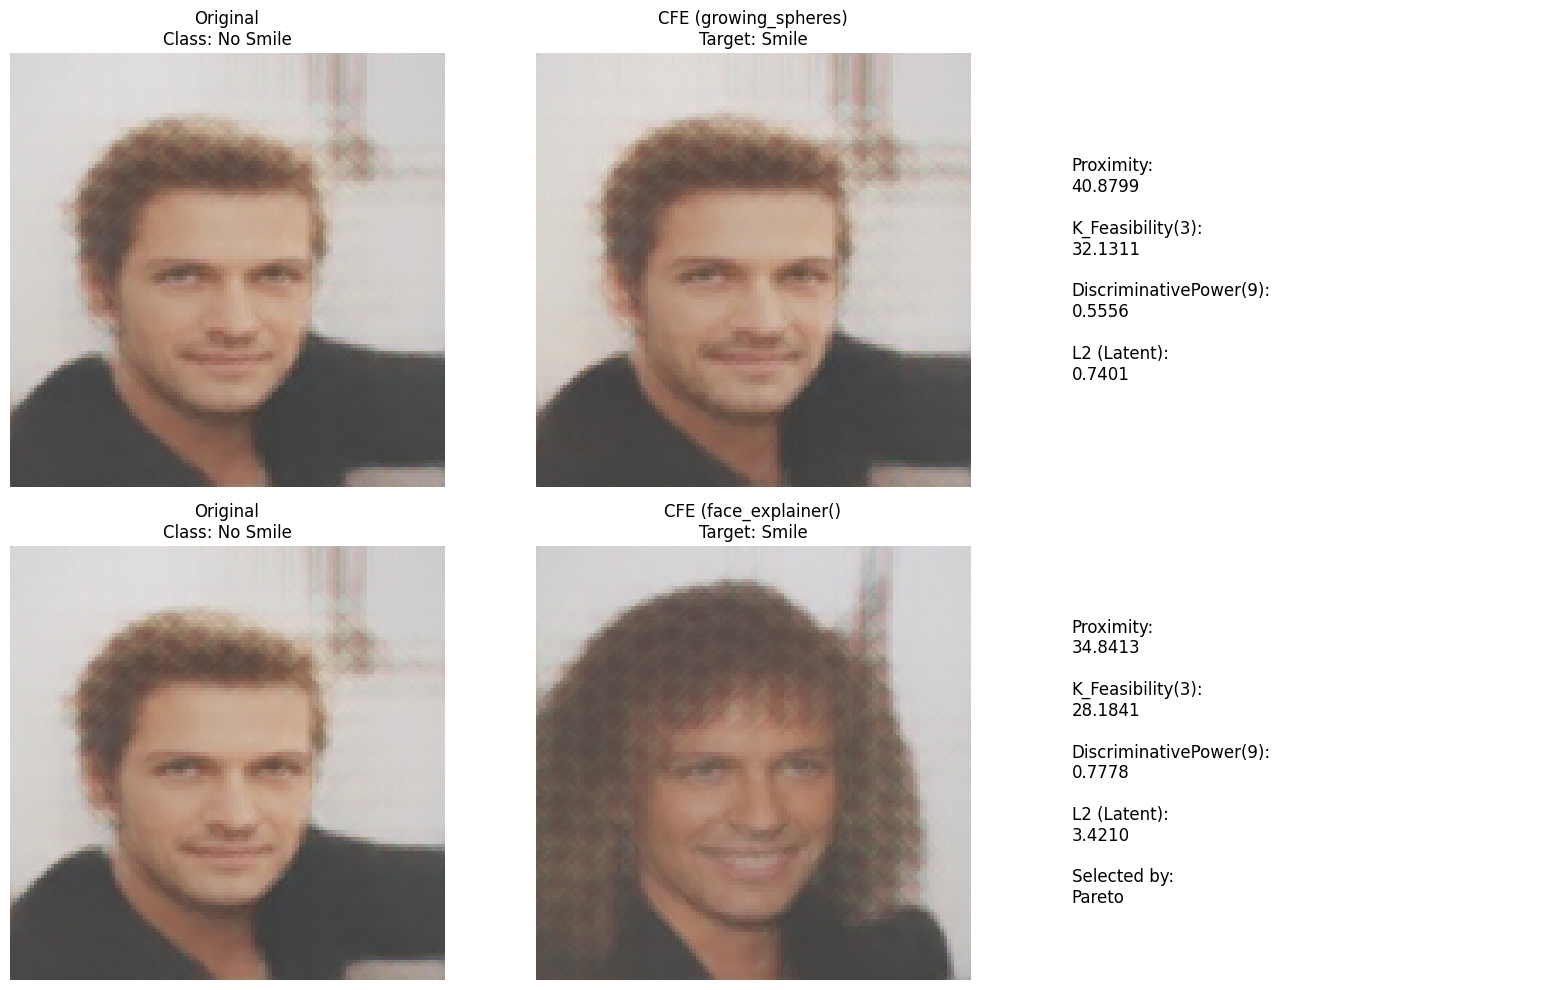

0.004279418623312106
0.09143144


In [12]:
c1, c2 = scored_cfs[5:7]
plot_scored_cfes([c1, c2], decoder, device)

print(((c1.original_data - c1.data)**2).mean() )
print(((c2.original_data - c2.data)**2).mean())


In [13]:
# Suma odległości L1 (Manhattan distance)
l1_c1 = torch.abs(torch.tensor(c1.original_data - c1.data)).sum().item()
l1_c2 = torch.abs(torch.tensor(c2.original_data - c2.data)).sum().item()

print(f"L1 (Manhattan) dla growing_spheres: {l1_c1:.4f}")
print(f"L1 (Manhattan) dla face_explainer: {l1_c2:.4f}")


L1 (Manhattan) dla growing_spheres: 5.4705
L1 (Manhattan) dla face_explainer: 30.5490
